# Dataset Diagnostics

## Objective

This notebook validates the final combined dataset before predictive modeling.

The goals are:

- Verify dataset size
- Verify target distributions
- Analyze temporal patterns
- Check serviceability score behavior
- Identify potential modeling challenges

The analysis will help determine the appropriate training, validation, and testing strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
combined_df = pd.read_parquet(
    "../data/processed/master_dataset_2018.parquet"
)

combined_df.shape

(1285434, 49)

## Dataset Overview

The combined dataset contains all mortgage loans from 2018 Q1–Q4.

Each record represents a single loan and includes:

- Origination characteristics
- Financial stress outcomes
- Borrower Serviceability Stress Index (BSSI)
- Borrower Serviceability Score (BSS)

This dataset will be used for all subsequent modeling experiments.

In [3]:
combined_df.head()

,credit_score,first_payment_date,first_time_homebuyer_indicator,maturity_date,msa,mortgage_insurance_pct,num_units,occupancy_status,cltv,dti,original_upb,ltv,interest_rate,channel,prepayment_penalty_indicator,amortization_type,property_state,property_type,postal_code,loan_identifier,loan_purpose,original_loan_term,num_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator,mortgage_insurance_cancellation_indicator,max_delinquency,ever_ra,ever_modified,ever_assistance,bssi,stress_flag,credit_score_norm,dti_norm,interest_rate_norm,ltv_norm,num_borrowers_norm,bss,bss_bucket,bss_level,year,quarter,quarter_num
0,785.0,201803,N,204802,49180.0,0,1,I,80.0,34.0,63000,80.0,5.250,R,N,FRM,NC,CO,27000,F18Q10000001,P,360,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7,0,False,False,False,0,0,0.846336,0.326531,0.207547,0.666667,0.0,49.500970,Medium,3.0,2018,2018Q1,1
1,761.0,201804,N,203803,NaN,0,1,P,57.0,43.0,145000,57.0,4.250,R,N,FRM,OH,MH,44600,F18Q10000002,C,240,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7,1,False,False,False,1,1,0.789598,0.142857,0.358491,0.768889,0.0,46.169609,Low,2.0,2018,2018Q1,1
2,726.0,201804,N,203803,19430.0,0,1,P,46.0,15.0,160000,46.0,4.000,R,N,FRM,OH,SF,45300,F18Q10000003,P,240,2,Other sellers,MATRIX FINANCIAL SERVICES CORPORATION,NaN,NaN,9,NaN,7,N,7,0,False,False,False,0,0,0.706856,0.714286,0.396226,0.817778,1.0,68.144792,Very High,5.0,2018,2018Q1,1
3,678.0,201805,Y,204804,39100.0,0,1,P,72.0,39.0,135000,72.0,5.000,R,N,FRM,NY,SF,12500,F18Q10000004,P,360,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7,0,False,False,False,0,0,0.593381,0.224490,0.245283,0.702222,1.0,47.764241,Low,2.0,2018,2018Q1,1
4,798.0,201803,N,204802,NaN,0,1,S,66.0,17.0,125000,66.0,3.875,R,N,FRM,MN,SF,56300,F18Q10000005,P,360,2,Other sellers,"PNC BANK, NA",NaN,NaN,9,NaN,7,N,7,0,False,False,False,0,0,0.877069,0.673469,0.415094,0.728889,1.0,73.865808,Very High,5.0,2018,2018Q1,1


# Dataset Summary

Before modeling, we first verify the overall size of the dataset.

Understanding the number of observations and features helps determine whether the dataset is sufficiently large for machine learning experiments.

In [4]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Loans",
        "Number of Features"
    ],
    "Value": [
        combined_df.shape[0],
        combined_df.shape[1]
    ]
})

summary

,Metric,Value
0,Number of Loans,1285434
1,Number of Features,49


### Interpretation

The dataset contains all processed mortgage loans from 2018.

The large number of observations provides sufficient data for:

- Model training
- Validation
- Temporal testing
- Explainability analysis

The dataset size is expected to support robust machine learning experiments.

# Quarter Distribution

The combined dataset should contain loans from all four quarters of 2018.

This analysis verifies that each quarter has been successfully incorporated into the master dataset.

In [5]:
combined_df["quarter"].value_counts().sort_index()

quarter
2018Q1    296816
2018Q2    364502
2018Q3    336669
2018Q4    287447
Name: count, dtype: int64

In [6]:
quarter_counts = (
    combined_df["quarter"]
    .value_counts()
    .sort_index()
)

quarter_counts

quarter
2018Q1    296816
2018Q2    364502
2018Q3    336669
2018Q4    287447
Name: count, dtype: int64

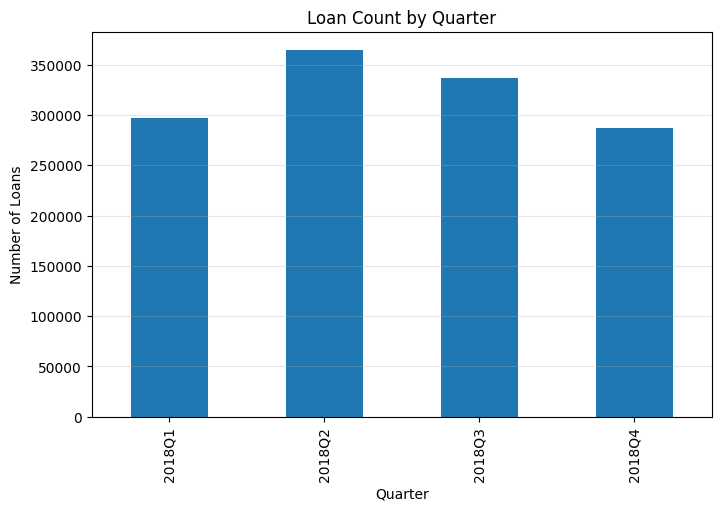

In [7]:
plt.figure(figsize=(8,5))

quarter_counts.plot(
    kind="bar"
)

plt.title(
    "Loan Count by Quarter"
)

plt.xlabel(
    "Quarter"
)

plt.ylabel(
    "Number of Loans"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Interpretation

The combined dataset contains approximately 1.29 million mortgage loans across all four quarters of 2018.

Loan volumes remain relatively stable across quarters, indicating that the dataset provides consistent temporal coverage throughout the year.

The inclusion of quarter information enables future temporal validation experiments and drift analysis.

# Financial Stress Distribution

Before developing predictive models, it is important to understand the distribution of the target variable.

This analysis evaluates the proportion of borrowers that experienced financial stress during the observation period.

The results will help determine whether class imbalance techniques are required during model development.

In [8]:
combined_df["stress_flag"].value_counts()

stress_flag
0    1108291
1     177143
Name: count, dtype: int64

In [9]:
stress_dist = (
    combined_df["stress_flag"]
    .value_counts(normalize=True)
    * 100
)

stress_dist

stress_flag
0    86.219207
1    13.780793
Name: proportion, dtype: float64

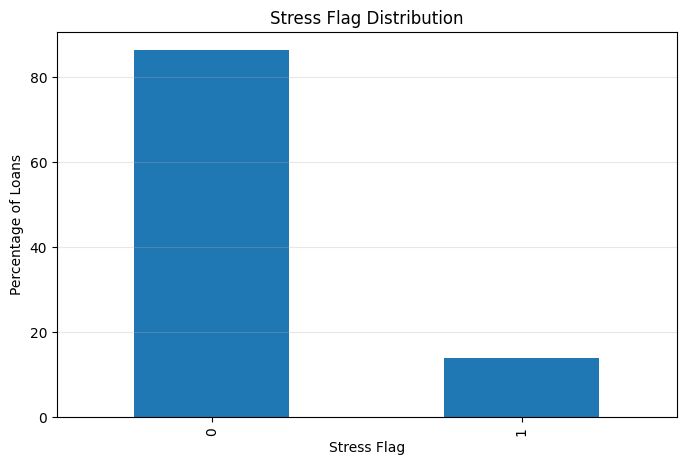

In [10]:
plt.figure(figsize=(8,5))

stress_dist.sort_index().plot(
    kind="bar"
)

plt.title(
    "Stress Flag Distribution"
)

plt.xlabel(
    "Stress Flag"
)

plt.ylabel(
    "Percentage of Loans"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Interpretation

The distribution illustrates the proportion of healthy and stressed borrowers within the portfolio.

A highly imbalanced distribution may require special handling during model development, such as:

- Class weighting
- Balanced sampling
- Alternative evaluation metrics

The observed distribution will guide the subsequent modeling strategy.

# Financial Stress by Quarter

The previous analysis evaluated overall stress prevalence.

This section investigates whether borrower stress varies across quarters.

Temporal variation in stress levels may indicate changing economic conditions or shifts in borrower characteristics.

In [11]:
quarter_stress = (
    combined_df.groupby("quarter")[
        "stress_flag"
    ]
    .mean()
    * 100
)

quarter_stress

quarter
2018Q1    14.414654
2018Q2    13.609253
2018Q3    13.738420
2018Q4    13.393426
Name: stress_flag, dtype: float64

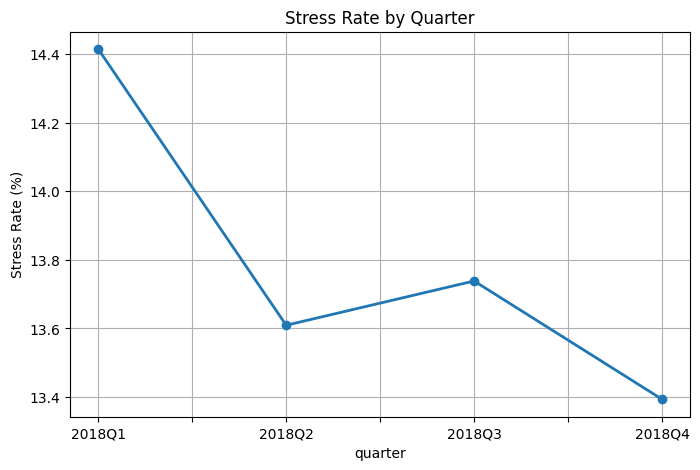

In [12]:
plt.figure(figsize=(8,5))

quarter_stress.plot(
    marker="o",
    linewidth=2
)

plt.title(
    "Stress Rate by Quarter"
)

plt.ylabel(
    "Stress Rate (%)"
)

plt.grid(True)

plt.show()

### Interpretation

Financial stress rates remain relatively stable across all four quarters of 2018.

The observed variation is small, suggesting that borrower stress patterns are consistent throughout the study period.

Although temporal validation remains valuable, the results indicate limited evidence of significant portfolio drift during 2018.

## Class Distribution Analysis

The financial stress target exhibits a moderate class imbalance.

Approximately 86% of borrowers remained financially healthy, while approximately 14% experienced financial stress during the observation period.

This distribution is consistent with real-world credit risk portfolios, where financially stressed borrowers typically represent a minority of the population.

Although the dataset is imbalanced, the stressed borrower class still contains a substantial number of observations, making the dataset suitable for supervised machine learning.

During model development, class weighting techniques will be considered to ensure adequate representation of stressed borrowers.

# Borrower Serviceability Stress Index (BSSI) Distribution

The Borrower Serviceability Stress Index (BSSI) represents the severity of borrower stress.

The index is defined as:

- BSSI = 0 : No observed stress
- BSSI = 1 : Moderate stress
- BSSI = 2 : Significant stress
- BSSI = 3 : Severe stress

This analysis evaluates the distribution of stress severity across the portfolio.

In [13]:
combined_df["bssi"].value_counts().sort_index()

bssi
0    1108291
1     131881
2      44527
3        735
Name: count, dtype: int64

In [14]:
(
    combined_df["bssi"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

bssi
0    86.219207
1    10.259648
2     3.463966
3     0.057179
Name: proportion, dtype: float64

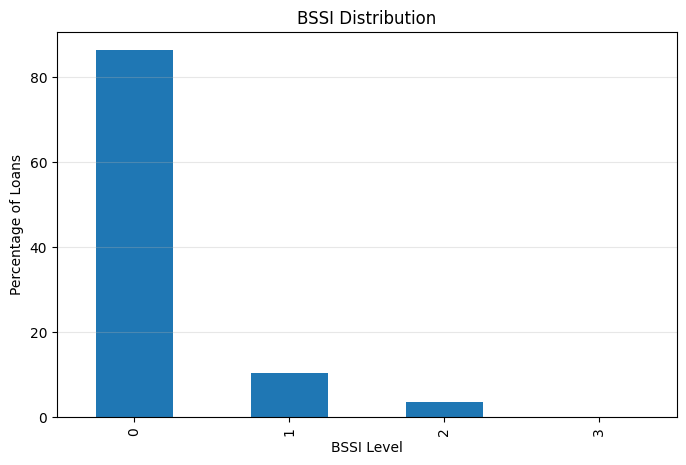

In [15]:
bssi_dist = (
    combined_df["bssi"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(8,5))

bssi_dist.plot(
    kind="bar"
)

plt.title(
    "BSSI Distribution"
)

plt.xlabel(
    "BSSI Level"
)

plt.ylabel(
    "Percentage of Loans"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Interpretation

The Borrower Serviceability Stress Index exhibits a highly skewed distribution.

Most borrowers (86.2%) experienced no observed financial stress, while progressively smaller proportions experienced moderate, significant, or severe stress.

The severe stress category represents a very small proportion of the portfolio, reflecting the rarity of extreme borrower distress within mortgage portfolios.

Given the limited number of observations within the most severe category, the primary predictive modeling task will focus on binary financial stress prediction using the Stress Flag target variable. The BSSI will be retained as a secondary severity measure for risk segmentation and interpretability analyses.

In [16]:
combined_df["bss"].describe()

count    1.271885e+06
mean     5.145062e+01
std      8.389237e+00
min      2.333581e+01
25%      4.548534e+01
50%      5.116133e+01
75%      5.722030e+01
max      8.466849e+01
Name: bss, dtype: float64

In [17]:
combined_df.groupby(
    "quarter"
)["bss"].mean()

quarter
2018Q1    52.320520
2018Q2    52.132186
2018Q3    51.801794
2018Q4    49.285490
Name: bss, dtype: float64

In [18]:
combined_df["bss_bucket"].value_counts(
    normalize=True
) * 100

bss_bucket
Very Low     20.000393
Medium       20.000157
Very High    20.000079
Low          19.999921
High         19.999450
Name: proportion, dtype: float64

### Serviceability Trends Across Quarters

Average Borrower Serviceability Scores remain relatively stable during the first three quarters of 2018.

A modest decline is observed during Q4, suggesting that borrowers originated later in the year exhibited slightly lower serviceability characteristics.

Although the decline is not substantial, the result highlights the importance of preserving temporal information within the dataset and supports the use of temporal validation strategies during model development.

# Diagnostic Summary

The combined dataset contains approximately 1.29 million mortgage loans across four quarters of 2018.

Key findings include:

- Financial stress affects approximately 14% of borrowers.
- Stress rates remain relatively stable across quarters.
- The Borrower Serviceability Stress Index exhibits a realistic severity distribution.
- The Borrower Serviceability Score demonstrates strong discriminatory power and stable behavior across time.
- Serviceability buckets provide balanced borrower segmentation.

The dataset is therefore considered suitable for predictive modeling and explainable AI analysis.